<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Maria_HeartCycle_RAWDATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RAW DATA**

SOBRE EL ARCHIVO **59146237_s0000001.mat**

In [ ]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

#from google.colab import files
# Upload the file from your local machine
#uploaded = files.upload()

filename = f'/content/59146237_s0000001.mat'
data_raw_HC =  sio.loadmat(filename)

About **IMPEDANCE**

<class 'numpy.ndarray'>
(1, 1)


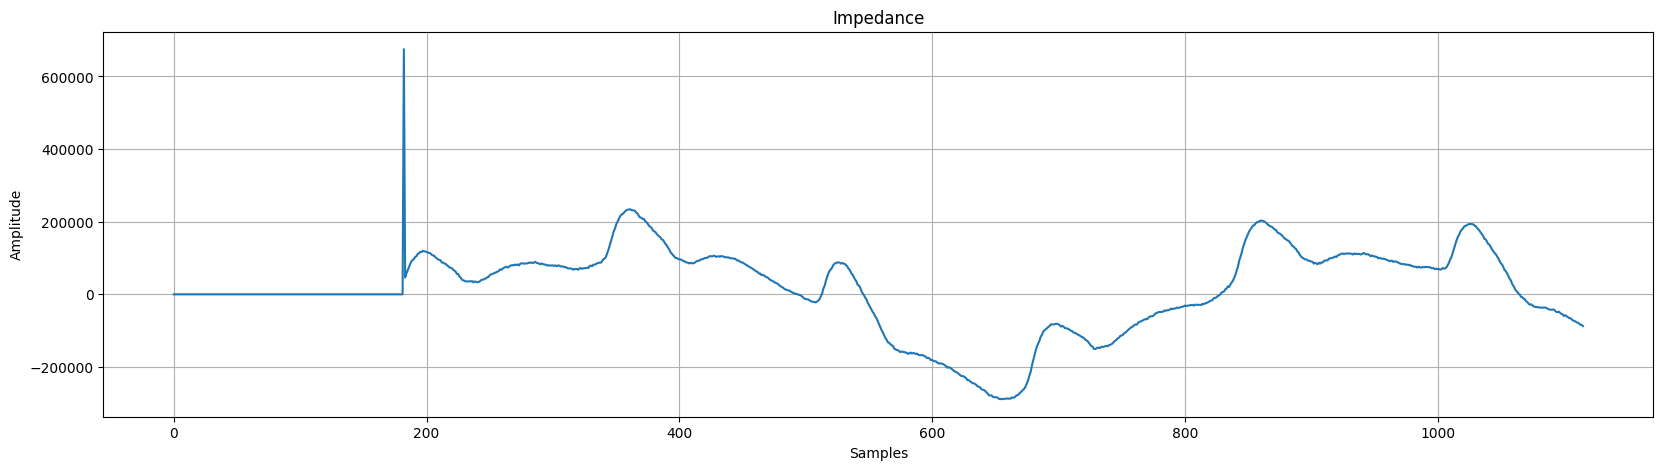

In [ ]:
#print(data_raw_HC.keys())
measures= data_raw_HC['measure']
#print(measures)
impedance=measures[1,1]
#print(impedance)
impedance_time=impedance['time']
#print(impedance_time)
impedance_data=impedance['data']
#print(impedance_data)
print(type(impedance_data))
print(impedance_data.shape) #impedance data is a 2D array

impedance_data_value = impedance_data[0, 0] #all the data is stored in [0,0]

plt.figure(figsize=(20, 5)) #if we have 250 samples per second and we want to plot 10 seconds, we will have to plot 2500 samples
plt.plot(impedance_data_value[0:1608])
plt.title('Impedance')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True) #adds a grid to the plot
plt.show() #displays the plot

Obtenemos que esta señal para visualizarla correctamente necesitamos filtrarla.

About **ECHOCARDIOGRAPHY**


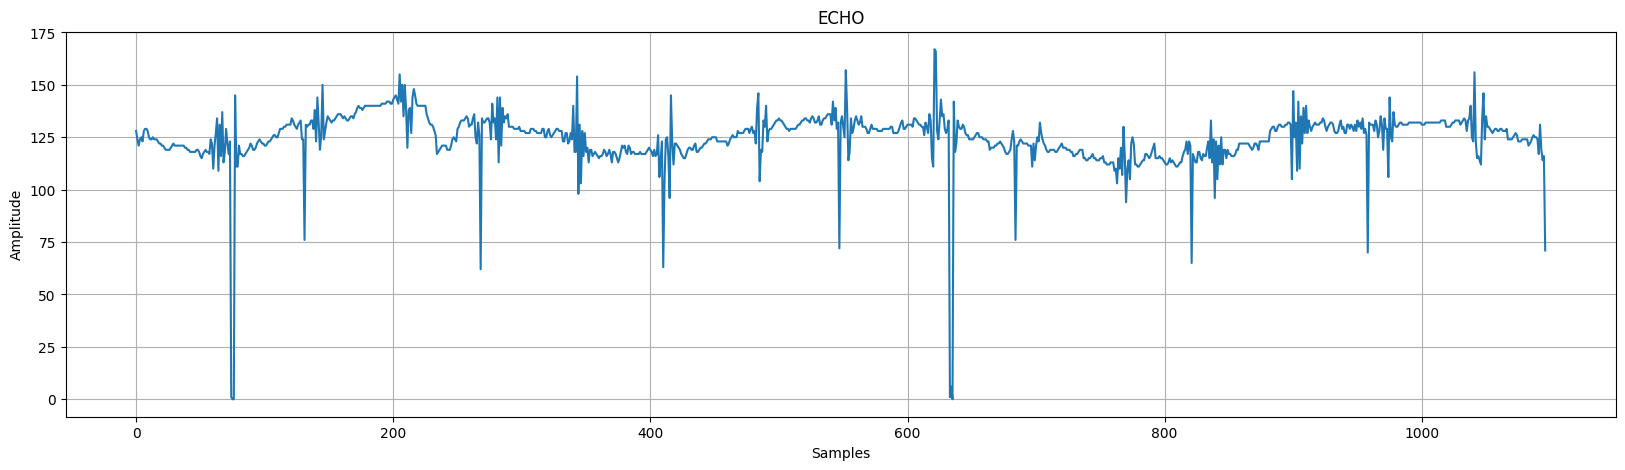

In [ ]:
ECHO=measures[1,3]
ECHO_time=ECHO['time']
ECHO_data=ECHO['data']
ECHO_data_value = ECHO_data[0, 0] #ECHO_data_value has the shape (100, 1097, 3),
#which means it contains 100 samples, 1097 time points, and 3 channels (or features).

#plt.figure(figsize=(20, 5)) #if we have 250 samples per second and we want to plot 10 seconds, we will have to plot 2500 samples
#plt.plot(ECHO_data_value[0:100])
#plt.title('ECHO')
#plt.xlabel('Samples')
#plt.ylabel('Amplitude')
#plt.grid(True) #adds a grid to the plot
#plt.show() #displays the plot

ECHO_data_value_channel_1 = ECHO_data_value[2, :, 0]  # Selecting the first channel

plt.figure(figsize=(20, 5))
plt.plot(ECHO_data_value_channel_1)  # Plotting the first 100 samples
plt.title('ECHO')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


About **ECG** with NICCOMO

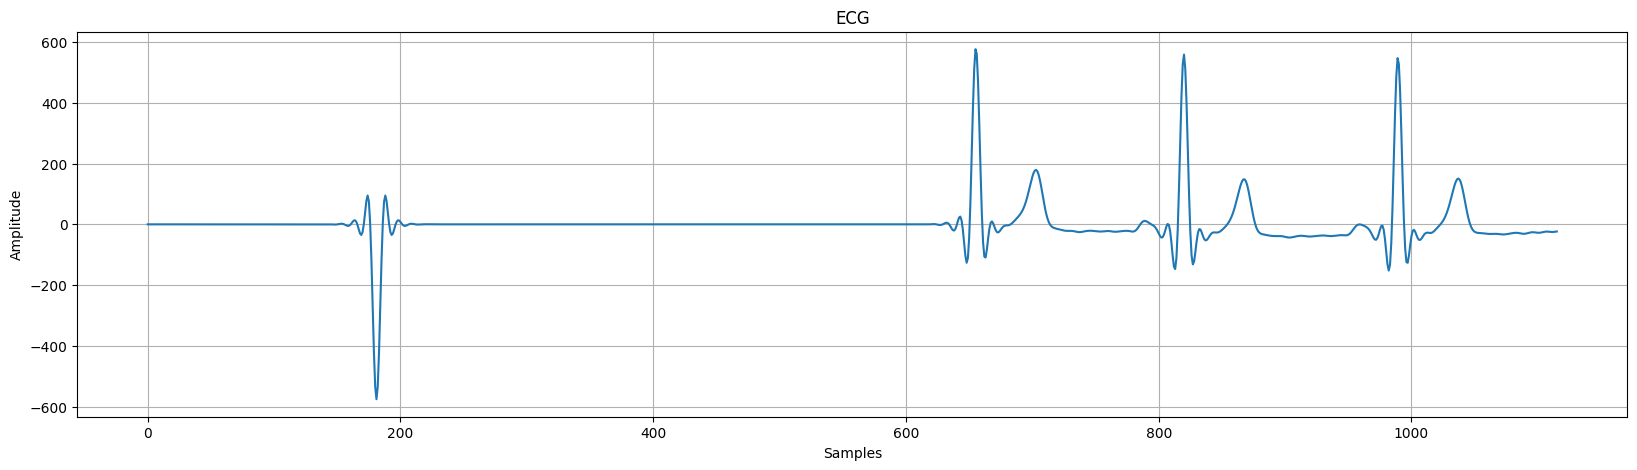

In [ ]:
ECG=measures[0,1]
ECG_time=ECG['time']
ECG_data=ECG['data']
ECG_data_value = ECG_data[0, 0]
plt.figure(figsize=(20, 5))
plt.plot(ECG_data_value[0:1608])
plt.title('ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

About **ECG** with STETHOSCOPE

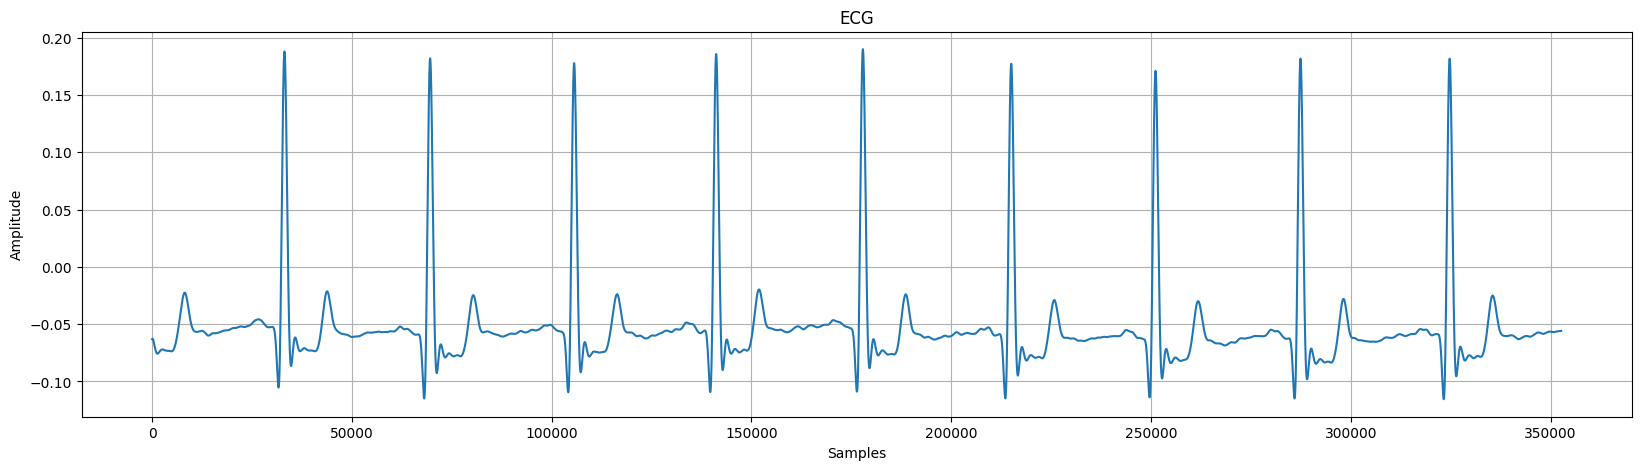

In [ ]:
ECG=measures[0,2]
ECG_time=ECG['time']
ECG_data=ECG['data']
ECG_data_value = ECG_data[0, 0]
plt.figure(figsize=(20, 5))
plt.plot(ECG_data_value[0:352661])
plt.title('ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Me proporciona información más confiable el ECG con esta técnica frente al NICCOMO.


About **ECG** with ECHOCARDIOGRAM

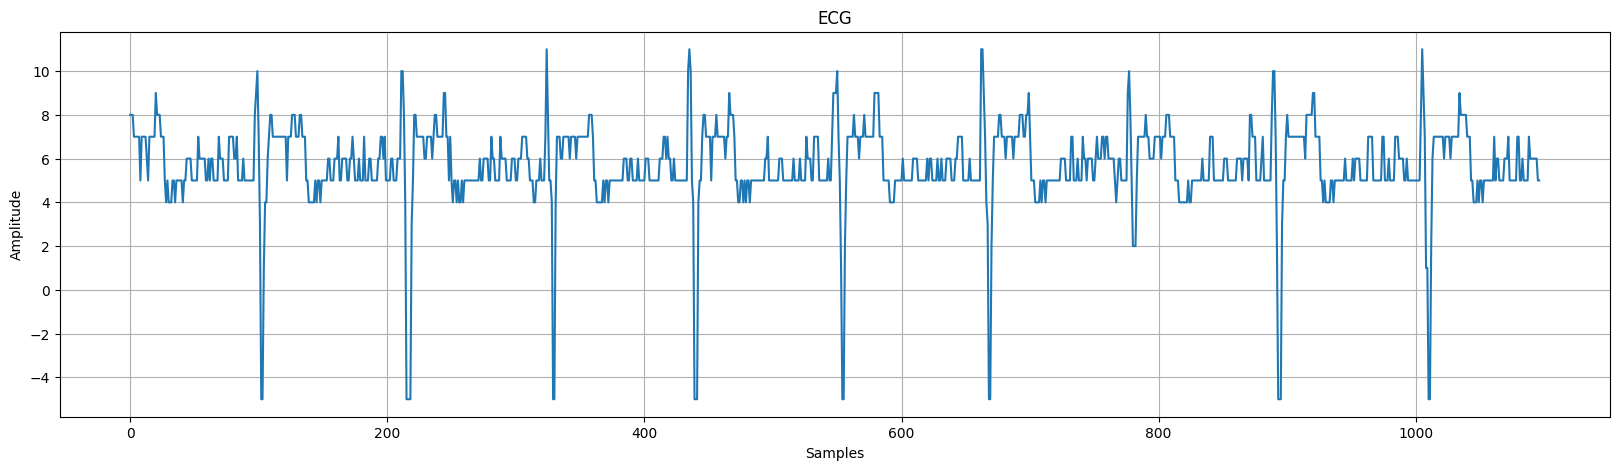

In [ ]:
ECG=measures[0,3]
ECG_time=ECG['time']
ECG_data=ECG['data']
ECG_data_value = ECG_data[0, 0]
plt.figure(figsize=(20, 5))
plt.plot(ECG_data_value[0:1097])
plt.title('ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Se obtiene con mucho ruido.

About **ECG** with PPG

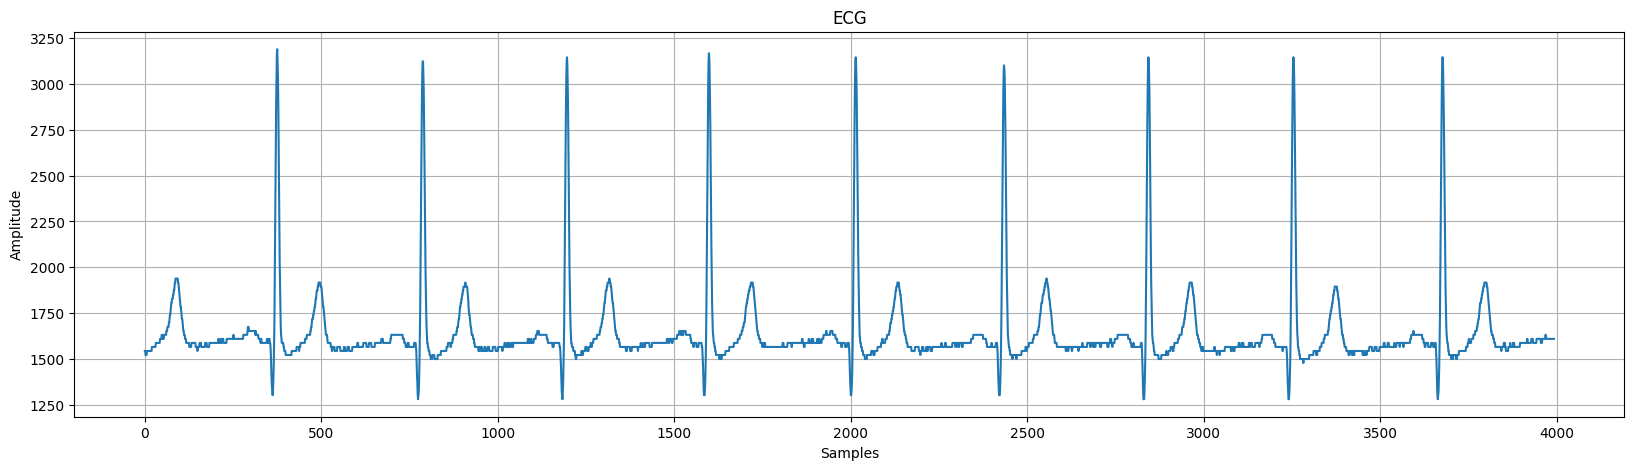

In [ ]:
ECG=measures[0,4]
ECG_time=ECG['time']
ECG_data=ECG['data']
ECG_data_value = ECG_data[0, 0]
plt.figure(figsize=(20, 5))
plt.plot(ECG_data_value[0:3993])
plt.title('ECG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Obtenemos el ECG con un poco de ruido pero no tiene tampoco mala calidad.

**Conclusión sobre ECG**:
Se obtiene el ECG a partir de 4 técnicas diferentes. Mejor técnica en base a los resultados obtenidos: About ECG with STETHOSCOPE. Tiene mucho sentido ya que la frecuencia de muestreo es muy elevada y por tanto se obtienen muchas muestras denotando que la información ploteada es confiable. Las técnicas PPG y ECHO al tener una frecuencia de muestreo inferior, obtienen un número inferior de muestras y la información ploteada aparece más discretizada, no tan continua. Por último, NICCOMO no lo veo una técnica muy confiable ya que únicamente representa los últimos latidos.

Now we are going to implement the R peak detection in the ECG with stethoscope code.

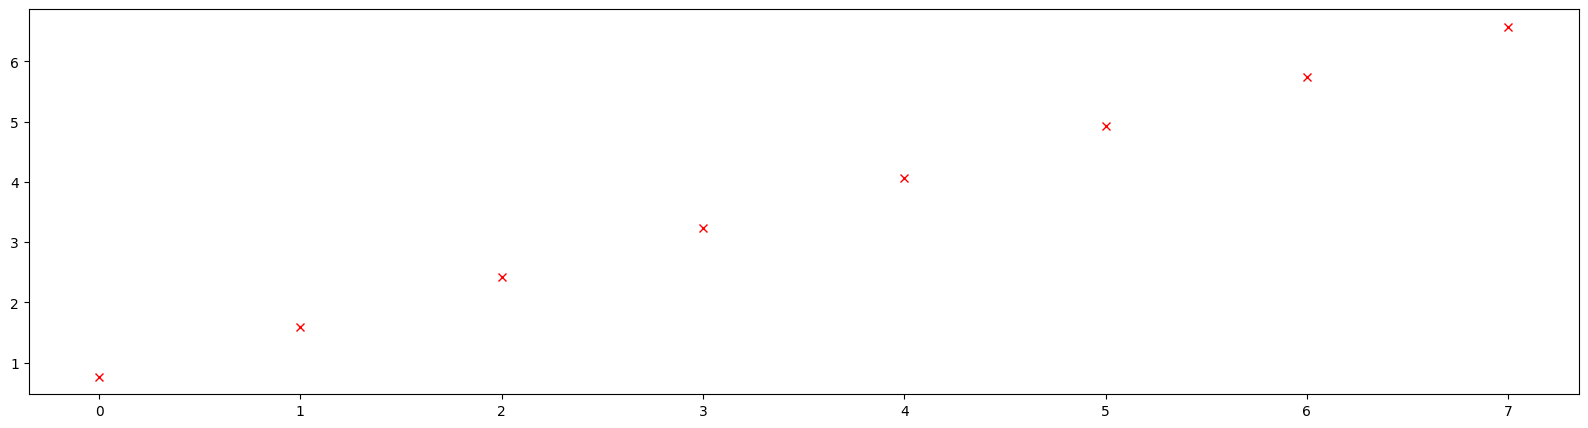

In [ ]:
R_PEAKS=measures[2,2]
R_PEAKS_time=R_PEAKS['time']
R_PEAKS_data=R_PEAKS['data']
R_PEAKS_data_value= R_PEAKS_data[0,0]
plt.figure(figsize=(20, 5))
plt.plot(R_PEAKS_data_value[0:8], color='red', marker='x',linestyle='none', label='R peaks')

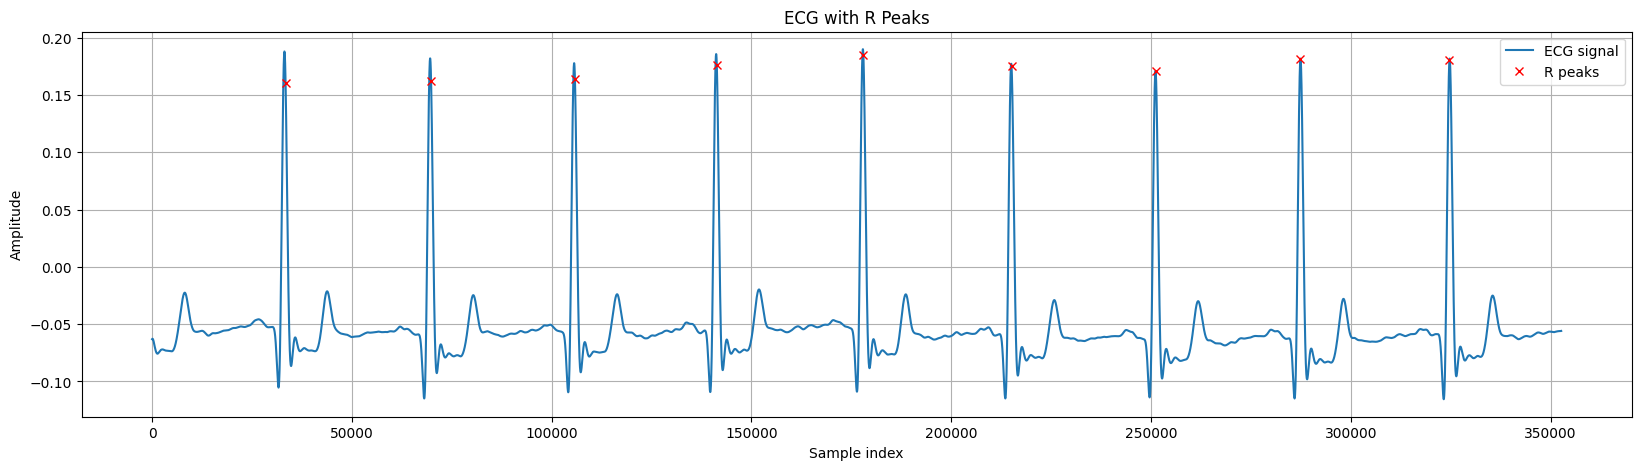

In [ ]:
fs = 43710.41
#This sample frequency has been calculated knowing that Number of samples = 352661, and
#duration = 8.0662 seconds. This has been obtained in the ECG.

#KEY: we have to convert R peaks in order to hold on its plot to the ECG one. This is because
#X axis of R peaks are seconds and X axis of ECG are samples.

# ECG
ECG = measures[0, 2]
ECG_data = ECG['data']
ECG_data_value = ECG_data[0, 0]

# R peaks
R_PEAKS = measures[2, 2]
R_PEAKS_data = R_PEAKS['data'][0, 0].flatten()  # it is confusing but the data gives us the TIME where the R peak occurs
R_PEAKS_indices = (R_PEAKS_data * fs).astype(int)  # Convert to sample indices
R_PEAKS_amplitude = ECG_data_value[R_PEAKS_indices]  # ECG values at R peaks

# Plot
plt.figure(figsize=(20, 5))
plt.plot(ECG_data_value, label='ECG signal')
plt.plot(R_PEAKS_indices, R_PEAKS_amplitude, 'rx', label='R peaks')
plt.title('ECG with R Peaks')
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


About **PHONOCARDIOGRAPHY**


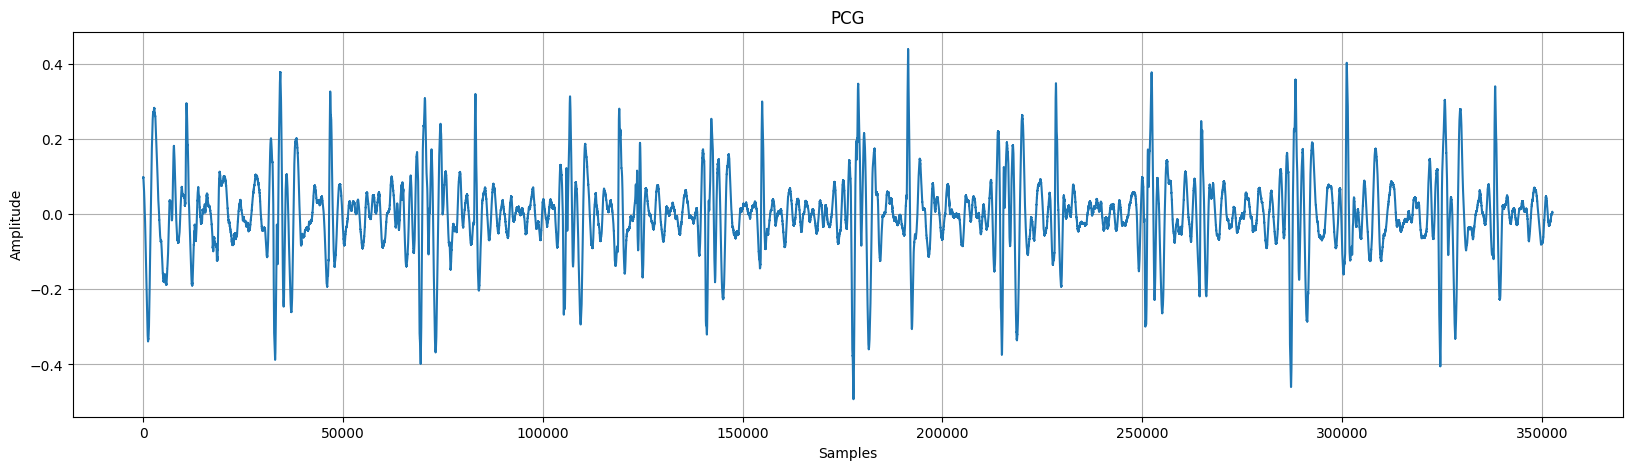

In [ ]:
PCG=measures[1,2]
PCG_time=PCG['time']
PCG_data=PCG['data']
PCG_data_value = PCG_data[0, 0]
plt.figure(figsize=(20, 5))
plt.plot(PCG_data_value[0:352660])
plt.title('PCG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


About **PLETHYSMOGRAPHY**

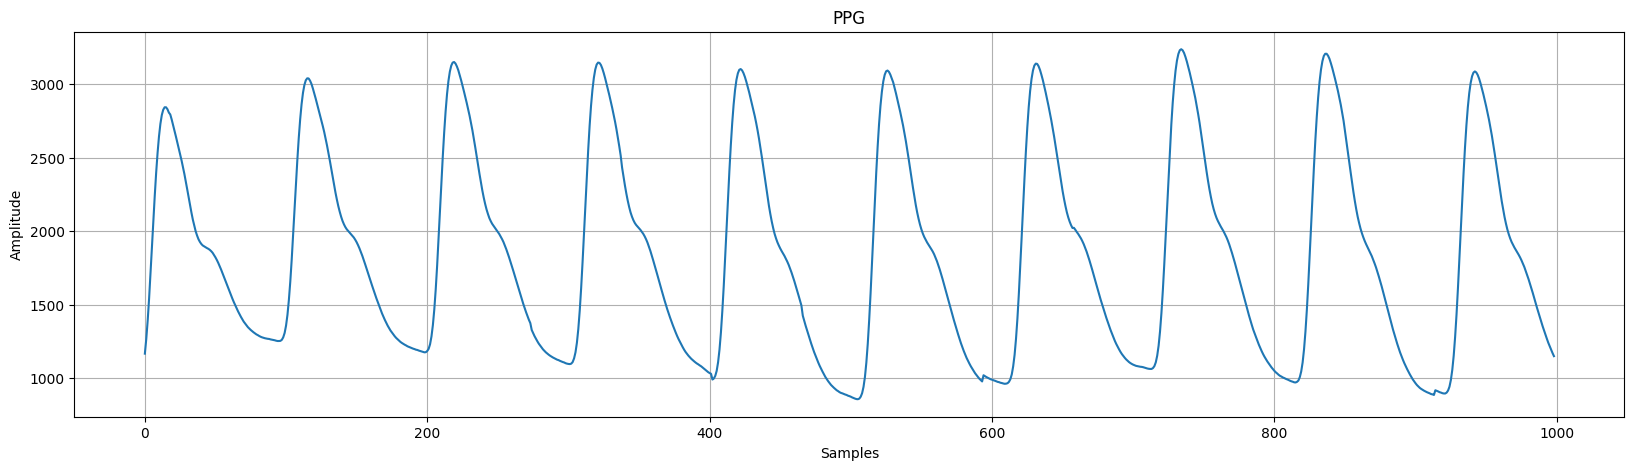

In [ ]:
PPG=measures[1,4]
PPG_time=PPG['time']
PPG_data=PPG['data']
PPG_data_value = PPG_data[0, 0]
plt.figure(figsize=(20, 5))
plt.plot(PPG_data_value[0:999])
plt.title('PPG')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


















We are going to plot together ECHO and ICG and see what is the correspondece

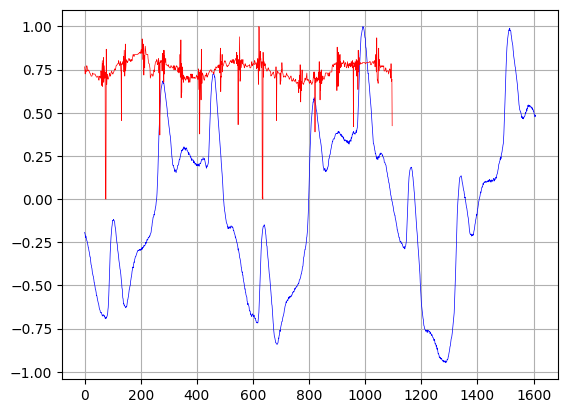

In [ ]:
def normalizar_rango(senal):
    """
    Normaliza la señal en el rango [-1, 1].
    """
    max_abs = np.max(np.abs(senal))  # Encuentra el valor absoluto máximo
    if max_abs == 0:
        return senal  # Evita división por cero si la señal es constante
    return senal / max_abs  # Escala la señal

impedance_normalizada=normalizar_rango(impedance_data_value[0:1608])
ECHO_normalizada=normalizar_rango(ECHO_data_value_channel_1)

plt.plot(impedance_normalizada, color='blue', linewidth=0.5)
plt.plot(ECHO_normalizada, color='red', linewidth=0.5)
plt.grid(True)
plt.show()

Me da un resultado muy raro pq las señales no están preprocesadas.